- Mount với folder trong drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


- Dùng !pip install để tải các thư viện phù hợp sau đó import vào

In [ ]:
# !pip install kneed
# !pip install apyori



/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5955 sha256=e38db208b02e25679ef04dae190a69f3eb8467026ede4ff7e00a1c3ba8e4d422
  Stored in directory: /root/.cache/pip/wheels/c4/1a/79/20f55c470a50bb3702a8cb7c94d8ada15573538c7f4baebe2d
Successfully built apyori


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore') # Bất kỳ cảnh báo nào xuất hiện trong quá trình thực thi chương trình sẽ không hiển thị ra ngoài màn hình
from ast import literal_eval # biểu thị và đánh giá các dữ liệu cơ bản như danh sách (list), từ điển (dictionary), số nguyên (integer), số thực (float), chuỗi (string), và các giá trị boolean
from sklearn.feature_extraction.text import TfidfVectorizer #chuyển đổi các tập dữ liệu thô thành ma trận TF-IDF (NLP)
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel #tính toán độ tương tự cosine giữa các mẫu, #linear_kernel tính toán giữa 2 ma trận
from sklearn.neighbors import NearestNeighbors #KNN
from sklearn.decomposition import TruncatedSVD #dùng để giảm chiều dữ liệu
from sklearn.decomposition import PCA #giảm chiều dữ liệu (principal component analysis)
from sklearn.cluster import KMeans #kmeans
from sklearn.metrics import silhouette_score #tính toán hệ số tương quan giữa các mẫu
from kneed import KneeLocator #dùng để xác định điểm gập để chọn số cụm và số lớp
from mlxtend.frequent_patterns import apriori, association_rules #các luật kết hợp
import re
import string
from apyori import apriori

import seaborn as sns
%matplotlib inline

# .set options

In [ ]:
# display all columns of the dataframe
pd.options.display.max_columns = None
# display all rows of the dataframe
pd.options.display.max_rows = None
# return an output value upto 6 decimals
pd.options.display.float_format = '{:.6f}'.format

# Đọc dữ liệu. (File: anime.csv, rating.csv)

In [ ]:
anime = pd.read_csv("/content/drive/My Drive/BTLdataMining/anime.csv") #đọc file bằng thư viện pandas, hiển thị ở dưới là 1 dataframe
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.260000,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.250000,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.170000,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.160000,151266


In [ ]:
anime.shape #số rows và số column của dữ liệu

(12294, 7)

In [ ]:
anime.info() #đọc kiểu dữ liệu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [ ]:
rating = pd.read_csv("/content/drive/My Drive/BTLdataMining/rating.csv",sep=",") #đọc file rating.csv và seperate bằng dấu ,
rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [ ]:
rating.shape #xem số row và số column của file

(7813737, 3)

In [ ]:
rating.info() #kiểu dữ liệu của file

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


# Phân tích và xử lí dữ liệu
## Làm sạch dữ liệu anime

In [ ]:
# Hiển thị tên phim trong anime
anime["name"].unique()[1:10], anime["name"].unique()

(array(['Fullmetal Alchemist: Brotherhood', 'Gintama°', 'Steins;Gate',
        'Gintama&#039;',
        'Haikyuu!!: Karasuno Koukou VS Shiratorizawa Gakuen Koukou',
        'Hunter x Hunter (2011)', 'Ginga Eiyuu Densetsu',
        'Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare',
        'Gintama&#039;: Enchousen'], dtype=object),
 array(['Kimi no Na wa.', 'Fullmetal Alchemist: Brotherhood', 'Gintama°',
        ..., 'Violence Gekiga David no Hoshi',
        'Violence Gekiga Shin David no Hoshi: Inma Densetsu',
        'Yasuji no Pornorama: Yacchimae!!'], dtype=object))

string.punctuation: https://www.geeksforgeeks.org/string-punctuation-in-python/ -- nhóm em tham khảo ở link này

In [ ]:
# Hàm này dùng để loại bỏ các ký tự thừa và lỗi, dùng
def text_cleaning(text):
    text = re.sub(r'&quot;', "", text)
    #string.punctuation : lấy ra các dấu -> replace thành ""
    text  = "".join([char for char in text if char not in string.punctuation])
    text = re.sub(r'.hack//', '', text)
    text = re.sub(r'&#039;', '', text)
    text = re.sub(r'A&#039;s', '', text)
    text = re.sub(r'I&#039;', 'I\'', text)
    text = re.sub(r'&amp;', 'and', text)
    text = re.sub(r'Â°', '',text)

    return text

thực hiện xóa các tên lỗi và xem các tên anime sau khi xử lí

In [ ]:
anime["name"] = anime["name"].apply(text_cleaning) # thực hiện clean với column name

In [ ]:
anime['name'].unique(), anime["name"].unique()[1:10]

(array(['Kimi no Na wa', 'Fullmetal Alchemist Brotherhood', 'Gintama°',
        ..., 'Violence Gekiga David no Hoshi',
        'Violence Gekiga Shin David no Hoshi Inma Densetsu',
        'Yasuji no Pornorama Yacchimae'], dtype=object),
 array(['Fullmetal Alchemist Brotherhood', 'Gintama°', 'SteinsGate',
        'Gintama039',
        'Haikyuu Karasuno Koukou VS Shiratorizawa Gakuen Koukou',
        'Hunter x Hunter 2011', 'Ginga Eiyuu Densetsu',
        'Gintama Movie Kanketsuhen  Yorozuya yo Eien Nare',
        'Gintama039 Enchousen'], dtype=object))

In [ ]:
anime["episodes"].unique() # xem các dữ liệu unique trên cột episodes (tập phim), ta thấy có xuất hiện unknown

array(['1', '64', '51', '24', '10', '148', '110', '13', '201', '25', '22',
       '75', '4', '26', '12', '27', '43', '74', '37', '2', '11', '99',
       'Unknown', '39', '101', '47', '50', '62', '33', '112', '23', '3',
       '94', '6', '8', '14', '7', '40', '15', '203', '77', '291', '120',
       '102', '96', '38', '79', '175', '103', '70', '153', '45', '5',
       '21', '63', '52', '28', '145', '36', '69', '60', '178', '114',
       '35', '61', '34', '109', '20', '9', '49', '366', '97', '48', '78',
       '358', '155', '104', '113', '54', '167', '161', '42', '142', '31',
       '373', '220', '46', '195', '17', '1787', '73', '147', '127', '16',
       '19', '98', '150', '76', '53', '124', '29', '115', '224', '44',
       '58', '93', '154', '92', '67', '172', '86', '30', '276', '59',
       '72', '330', '41', '105', '128', '137', '56', '55', '65', '243',
       '193', '18', '191', '180', '91', '192', '66', '182', '32', '164',
       '100', '296', '694', '95', '68', '117', '151', '130',

In [ ]:
#thay thế dữ liệu "Unknow" = nan để dễ dàng xóa sau này
anime.episodes.replace({'Unknown':np.nan},inplace=True)

In [ ]:
anime["episodes"].unique() # kiểm tra lại cột episodes sau khi replace

array(['1', '64', '51', '24', '10', '148', '110', '13', '201', '25', '22',
       '75', '4', '26', '12', '27', '43', '74', '37', '2', '11', '99',
       nan, '39', '101', '47', '50', '62', '33', '112', '23', '3', '94',
       '6', '8', '14', '7', '40', '15', '203', '77', '291', '120', '102',
       '96', '38', '79', '175', '103', '70', '153', '45', '5', '21', '63',
       '52', '28', '145', '36', '69', '60', '178', '114', '35', '61',
       '34', '109', '20', '9', '49', '366', '97', '48', '78', '358',
       '155', '104', '113', '54', '167', '161', '42', '142', '31', '373',
       '220', '46', '195', '17', '1787', '73', '147', '127', '16', '19',
       '98', '150', '76', '53', '124', '29', '115', '224', '44', '58',
       '93', '154', '92', '67', '172', '86', '30', '276', '59', '72',
       '330', '41', '105', '128', '137', '56', '55', '65', '243', '193',
       '18', '191', '180', '91', '192', '66', '182', '32', '164', '100',
       '296', '694', '95', '68', '117', '151', '130', '87',

### Thực hiện nối 2 file dữ liệu là anime và rating để xử lí và dùng sau này

In [ ]:
anime_rating = pd.merge(anime, rating, on="anime_id") # dùng hàm merge để nối 2 bảng với nhau tạo dựa vào anime_id thành 1 bảng mới tên anime_rating
anime_rating.head(10)

,anime_id,name,genre,type,episodes,rating_x,members,user_id,rating_y
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,99,5
1,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,152,10
2,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,244,10
3,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,271,10
4,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,278,-1
5,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,322,10
6,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,398,10
7,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,462,8
8,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,490,10
9,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,548,10


In [ ]:
#đổi tên rating_x thành trung bình đánh giá bộ phim, rating_y thành số lượng người đánh gia
anime_rating.rename(columns={'rating_x':'avg_rating','rating_y':'user_rating'}, inplace=True)
anime_rating.head()

,anime_id,name,genre,type,episodes,avg_rating,members,user_id,user_rating
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,99,5
1,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,152,10
2,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,244,10
3,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,271,10
4,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,278,-1


In [ ]:
anime_rating.shape #xem số lượng hàng và cột của bảng sau khi nối (chiều dữ liệu)

(7813727, 9)

In [ ]:
anime_rating.info() #xem kiểu dữ liệu của bảng

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7813727 entries, 0 to 7813726
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   anime_id     int64  
 1   name         object 
 2   genre        object 
 3   type         object 
 4   episodes     object 
 5   avg_rating   float64
 6   members      int64  
 7   user_id      int64  
 8   user_rating  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 596.1+ MB


In [ ]:
anime_rating.dtypes

anime_id         int64
name            object
genre           object
type            object
episodes        object
avg_rating     float64
members          int64
user_id          int64
user_rating      int64
dtype: object

In [ ]:
#do kiểu dữ anime_id và user_id là duy nhất nên convert về kiểu object
anime_rating['anime_id'] = anime_rating.anime_id.astype('object')
anime_rating['user_id'] = anime_rating.user_id.astype('object')

In [ ]:
anime_rating.dtypes

anime_id        object
name            object
genre           object
type            object
episodes        object
avg_rating     float64
members          int64
user_id         object
user_rating      int64
dtype: object

### xử lý dữ liệu mất mát

In [ ]:
#đếm số lượng dữ liệu bị mất và tỉ lệ phần trăm dữ liệu bị mất so với toàn bộ
missing_value = pd.DataFrame({
    'Missing Value': anime_rating.isnull().sum(),
    'Percentage': (anime_rating.isnull().sum() / len(anime_rating))*100
})

In [ ]:
#dữ liệu bị mất quá nhỏ. Không đáng để mất công xử lí nên xóa nó đi cho nhanh
missing_value.sort_values(by='Percentage', ascending=False)

,Missing Value,Percentage
genre,110,0.001408
avg_rating,6,0.000077
type,4,0.000051
anime_id,0,0.000000
name,0,0.000000
episodes,0,0.000000
members,0,0.000000
user_id,0,0.000000
user_rating,0,0.000000


In [ ]:
## anime_rating.to_csv("anime_rating.csv") #lưu lại file để sau này dùng

In [ ]:
anime.isnull().sum() #đếm số lượng dữ liệu bị mất ở file anime

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [ ]:
import seaborn as sns
%matplotlib inline

<Axes: >

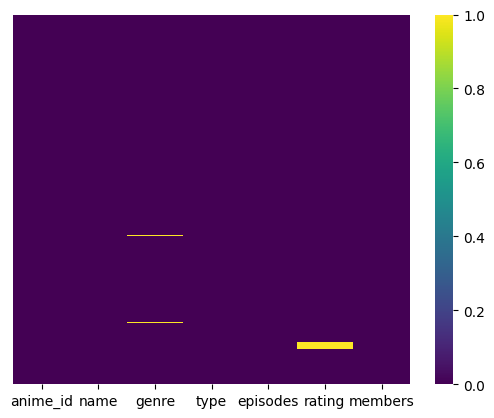

In [ ]:
sns.heatmap(anime.isnull(), yticklabels=False, cmap="viridis") #plot lên thì thấy dữ liệu mất mát không đáng kể

In [ ]:
anime_rating.isnull().sum() #đếm dữ liệu mất ở file anime_rating

anime_id         0
name             0
genre          110
type             4
episodes         0
avg_rating       6
members          0
user_id          0
user_rating      0
dtype: int64

In [ ]:
sns.heatmap(anime_rating.isnull(), yticklabels=False, cmap="viridis")

KeyboardInterrupt: ignored

Error in callback <function flush_figures at 0x7d83799e4b80> (for post_execute):


KeyboardInterrupt: ignored

In [ ]:
#Không thay thế giá trị nan bằng giá trị trung bình hoặc giá trị trung vị cho mỗi bộ phim
#vì nó quá tốn sức và quá ít nên không đáng bận tâm
#Nên xóa nó đi cho nhanh
anime_rating.dropna(inplace=True)
anime.dropna(inplace=True)

In [ ]:
anime.dropna(inplace=True)

In [ ]:
anime_rating.isnull().sum() #kiểm tra lại xem còn giá trị null hay không

anime_id       0
name           0
genre          0
type           0
episodes       0
avg_rating     0
members        0
user_id        0
user_rating    0
dtype: int64

In [ ]:
anime.isnull().sum() #cái này giống cái trên

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [ ]:
sns.heatmap(anime.isnull(), yticklabels=False, cmap="viridis")

<AxesSubplot:>

<AxesSubplot:>

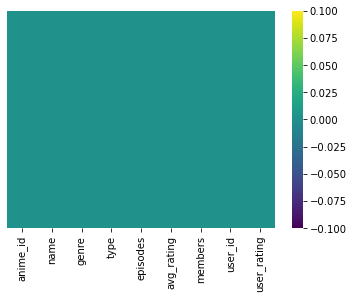

In [ ]:
sns.heatmap(anime_rating.isnull(), yticklabels=False, cmap="viridis") #vẽ lại rồi check thì thấy oke không sao

### Xử lí dữ liệu bị lặp lại trong mỗi bảng

In [ ]:
duplicate = anime_rating.duplicated(subset=['anime_id','user_id']).sum() #đếm số hàng bị lặp lại trong anime_id và user_id
print('There are {} duplicated rows in the data'.format(duplicate)) # có 7 hàng bị duplicated trong bộ dữ liệu anime_rating

There are 7 duplicated rows in the data


In [ ]:
duplicate = anime.duplicated().sum() #đếm số lượng bị lặp lại trong file anime
print('There are {} duplicated rows in the data'.format(duplicate)) #có 0 hàng bị lặp lại trong bộ dữ liệu anime

There are 0 duplicated rows in the data


In [ ]:
anime_rating.drop_duplicates(subset=['anime_id','user_id'],inplace=True)
# số lượng duplicate quá bé nên xóa nó đi cho nhanh
# Loại bỏ dữ liệu bị trùng lặp vì nó k cần thiết

In [ ]:
# kiểm tra lại số lượng lặp lại bằng hàm duplicated().sum()
duplicate = anime_rating.duplicated().sum()
print('There are {} duplicated rows in the data'.format(duplicate))

There are 0 duplicated rows in the data


In [ ]:
anime_rating.shape #đọc bộ dữ liệu sau khi làm sạch (số chiều số hàng và cột sau khi xử lí)

(7813604, 9)

In [ ]:
anime_rating.tail() #kiểm tra index không khớp

,anime_id,name,genre,type,episodes,avg_rating,members,user_id,user_rating
7813722,6133,Violence Gekiga Shin David no Hoshi Inma Densetsu,Hentai,OVA,1,4.980000,175,39532,-1
7813723,6133,Violence Gekiga Shin David no Hoshi Inma Densetsu,Hentai,OVA,1,4.980000,175,48766,-1
7813724,6133,Violence Gekiga Shin David no Hoshi Inma Densetsu,Hentai,OVA,1,4.980000,175,60365,4
7813725,26081,Yasuji no Pornorama Yacchimae,Hentai,Movie,1,5.460000,142,27364,-1
7813726,26081,Yasuji no Pornorama Yacchimae,Hentai,Movie,1,5.460000,142,48766,-1


In [ ]:
anime_rating.reset_index(drop=True,inplace=True) #reset lại index từ đầu
anime_rating.tail()

,anime_id,name,genre,type,episodes,avg_rating,members,user_id,user_rating
7813599,6133,Violence Gekiga Shin David no Hoshi Inma Densetsu,Hentai,OVA,1,4.980000,175,39532,-1
7813600,6133,Violence Gekiga Shin David no Hoshi Inma Densetsu,Hentai,OVA,1,4.980000,175,48766,-1
7813601,6133,Violence Gekiga Shin David no Hoshi Inma Densetsu,Hentai,OVA,1,4.980000,175,60365,4
7813602,26081,Yasuji no Pornorama Yacchimae,Hentai,Movie,1,5.460000,142,27364,-1
7813603,26081,Yasuji no Pornorama Yacchimae,Hentai,Movie,1,5.460000,142,48766,-1


## Bộ dữ liệu sau khi làm sạch

In [ ]:
anime_rating.shape

(7813604, 9)

In [ ]:
anime_rating.head()

,anime_id,name,genre,type,episodes,avg_rating,members,user_id,user_rating
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,99,5
1,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,152,10
2,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,244,10
3,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,271,10
4,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,278,-1


In [ ]:
anime_rating.to_csv("anime_rating.csv") #lưu nó lại

In [ ]:
anime_rating = pd.read_csv("anime_rating.csv") #từ đây phần mềm bị crash nên phải đọc lại

In [ ]:
anime_rating.describe() #đọc miêu tả dữ liệu của các cột (số lượng (count), trung bình (mean), độ lệch chuẩn (std))
# (giá trị nhỏ nhất (min), độ phân bổ dữ liệu (25%, 50%, 75%), giá trị lớn nhất(max))

,Unnamed: 0,anime_id,avg_rating,members,user_id,user_rating
count,7813604.000000,7813604.000000,7813604.000000,7813604.000000,7813604.000000,7813604.000000
mean,3906801.500000,8908.724906,7.653157,178622.979043,36727.988202,6.144073
std,2255593.330708,8883.596860,0.672975,188176.077047,20997.932808,3.727793
min,0.000000,1.000000,1.670000,29.000000,1.000000,-1.000000
25%,1953400.750000,1240.000000,7.270000,44030.000000,18974.000000,6.000000
50%,3906801.500000,6213.000000,7.680000,110470.000000,36791.000000,7.000000
75%,5860202.250000,14093.000000,8.130000,244268.000000,54758.000000,9.000000
max,7813603.000000,34519.000000,9.500000,1013917.000000,73516.000000,10.000000


- các giá trị -1 của cột user_rating là người dùng không đánh giá
- Nên sẽ đếm các người dùng không đánh giá, thay thế nó bằng nan và thực hiện xóa chúng

In [ ]:
anime_rating[anime_rating.user_rating==-1].shape #lấy shape của các giá trị user_rating = -1

(1476465, 10)

In [ ]:
anime_rating.user_rating.replace({-1:np.nan},inplace=True) # thay thế các giá trị -1 thành nan

In [ ]:
anime_rating.isnull().sum()

Unnamed: 0           0
anime_id             0
name                 0
genre                0
type                 0
episodes             0
avg_rating           0
members              0
user_id              0
user_rating    1476465
dtype: int64

<AxesSubplot:>

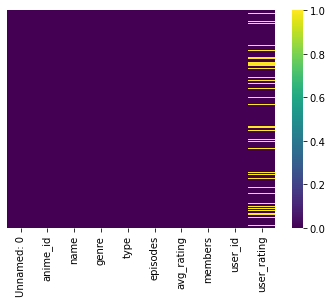

In [ ]:
sns.heatmap(anime_rating.isnull(), yticklabels=False, cmap="viridis") # xem các giá trị là null ở cột user_rating

In [ ]:
anime_rating.dropna(inplace=True) #thực hiện xóa các giá trị null trong cột

In [ ]:
anime_rating.isnull().sum()

Unnamed: 0     0
anime_id       0
name           0
genre          0
type           0
episodes       0
avg_rating     0
members        0
user_id        0
user_rating    0
dtype: int64

In [ ]:
anime_rating.shape #số chiều của dữ liệu sau khi xóa

(6337137, 10)

<AxesSubplot:>

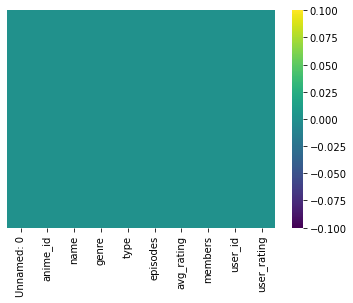

In [ ]:
sns.heatmap(anime_rating.isnull(), yticklabels=False, cmap="viridis") #dữ liệu sạch sau khi xóa

In [ ]:
anime_rating.describe()

,Unnamed: 0,anime_id,episodes,avg_rating,members,user_id,user_rating
count,6337137.000000,6337137.000000,6337137.000000,6337137.000000,6337137.000000,6337137.000000,6337137.000000
mean,3831677.211835,8902.535149,18.752744,7.675014,184576.391914,36747.954366,7.808545
std,2252641.631542,8881.663730,35.209369,0.669904,190952.794333,21013.380806,1.572436
min,0.000000,1.000000,1.000000,2.000000,33.000000,1.000000,1.000000
25%,1872770.000000,1239.000000,3.000000,7.290000,46803.000000,18985.000000,7.000000
50%,3799888.000000,6213.000000,12.000000,7.700000,117091.000000,36815.000000,8.000000
75%,5771647.000000,14075.000000,24.000000,8.150000,256325.000000,54873.000000,9.000000
max,7813597.000000,34475.000000,1818.000000,9.370000,1013917.000000,73516.000000,10.000000


--- category variable

In [ ]:
anime_rating.describe(include='object') # miêu tả tất cả dữ liệu kiểu object

,name,genre,type
count,6337137,6337137,6337137
unique,9869,3048,6
top,Death Note,"Comedy, School, Slice of Life",TV
freq,34226,49850,4364286


Từ bảng trên ta có thể thấy được:

- Có 9869 anime_id duy nhất và id anime được xem nhiều nhất là Dead Note với tần suất 34226.

- Có 9869 tên anime và tên anime được xem nhiều nhất là Death Notea và 34226 người đã xem.

- Có 3048 thể loại duy nhất và Comedy, School, Slice of Life là những thể loại được lặp lại nhiều nhất với tần suất 49850.

- Có 6 giá trị duy nhất trong thuộc tính loại và hầu hết loại là TV có tần số 4364286.

- Episodes chỉ định số tập của anime cụ thể đó.

- Có 69600 người dùng và người dùng có user_id 42635 là người dùng nhiều nhất đã xem hầu hết các animes.i.e. 3747 animes.

In [ ]:
## anime_rating.to_csv("anime_rating.csv")

## Sự tương quan giữa dữ liệu

In [ ]:
corr_matrix = anime_rating.corr() #xem sự tương quan dữ liệu qua dạng bảng
corr_matrix

,Unnamed: 0,anime_id,avg_rating,members,user_id,user_rating
Unnamed: 0,1.000000,0.011048,-0.956049,-0.555409,0.009169,-0.392832
anime_id,0.011048,1.000000,-0.025334,0.003211,-0.031084,-0.013231
avg_rating,-0.956049,-0.025334,1.000000,0.541074,-0.007908,0.410683
members,-0.555409,0.003211,0.541074,1.000000,-0.015406,0.232404
user_id,0.009169,-0.031084,-0.007908,-0.015406,1.000000,0.001879
user_rating,-0.392832,-0.013231,0.410683,0.232404,0.001879,1.000000


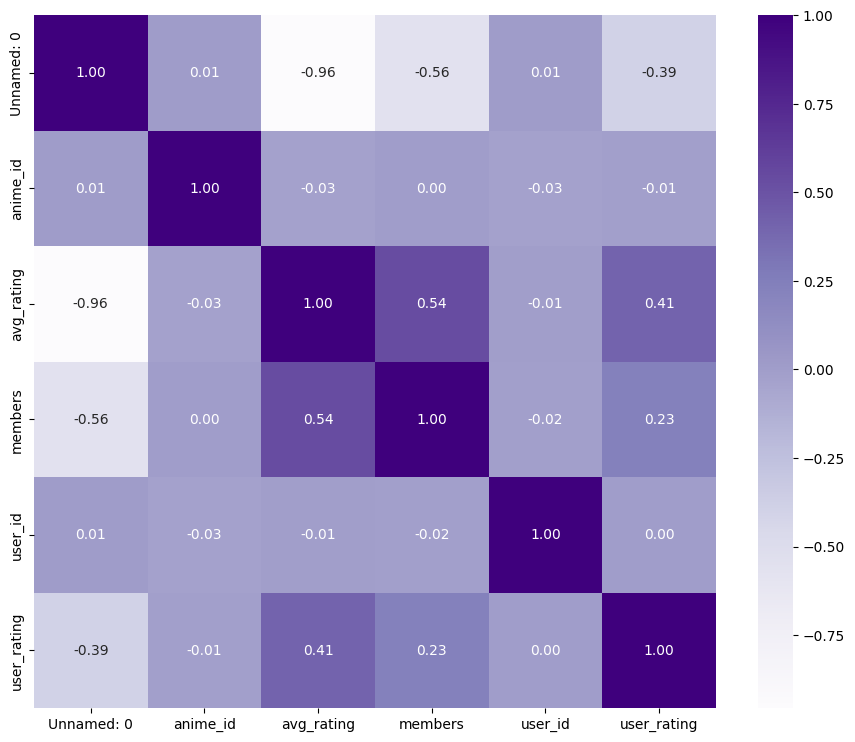

In [ ]:
#thực hiện plot lên để xem sự tương quan giữa dữ liệu
plt.figure(figsize=(11,9))
sns.heatmap(corr_matrix, cmap='Purples', annot=True, fmt=".2f")
sns.set(font_scale=1.5)

#Các thành viên và avg_rating có mối quan hệ tích cực. Tức là. 0,54.
# Bởi vì khi số lượng thành viên tăng thì xếp hạng trung bình của anime cũng sẽ tăng lên.
#Không có mối quan hệ mạnh mẽ nào với bất kỳ thuộc tính nào.

In [ ]:
# cái này định vẽ biểu đồ scatter lên nhưng nó nhiều chạy lâu quá nên bỏ
pd.plotting.scatter_matrix(anime_rating)

array([[<AxesSubplot:xlabel='Unnamed: 0', ylabel='Unnamed: 0'>,
        <AxesSubplot:xlabel='anime_id', ylabel='Unnamed: 0'>,
        <AxesSubplot:xlabel='episodes', ylabel='Unnamed: 0'>,
        <AxesSubplot:xlabel='avg_rating', ylabel='Unnamed: 0'>,
        <AxesSubplot:xlabel='members', ylabel='Unnamed: 0'>,
        <AxesSubplot:xlabel='user_id', ylabel='Unnamed: 0'>,
        <AxesSubplot:xlabel='user_rating', ylabel='Unnamed: 0'>],
       [<AxesSubplot:xlabel='Unnamed: 0', ylabel='anime_id'>,
        <AxesSubplot:xlabel='anime_id', ylabel='anime_id'>,
        <AxesSubplot:xlabel='episodes', ylabel='anime_id'>,
        <AxesSubplot:xlabel='avg_rating', ylabel='anime_id'>,
        <AxesSubplot:xlabel='members', ylabel='anime_id'>,
        <AxesSubplot:xlabel='user_id', ylabel='anime_id'>,
        <AxesSubplot:xlabel='user_rating', ylabel='anime_id'>],
       [<AxesSubplot:xlabel='Unnamed: 0', ylabel='episodes'>,
        <AxesSubplot:xlabel='anime_id', ylabel='episodes'>,
        <Axe

Error in callback <function flush_figures at 0x00000191D99D6CA0> (for post_execute):


KeyboardInterrupt: 

In [ ]:
from wordcloud import WordCloud
from collections import defaultdict

### Phân tích các tính năng

In [ ]:
nonull_anime = anime_rating.copy()
nonull_anime.dropna(inplace=True)

In [ ]:
all_genres = defaultdict(int)

#Thực hiện tách các thể loại anime bằng dấu phẩy để đánh giá thể loại nào được nhiều người xem nhất
for genres in nonull_anime['genre']:
    for genre in genres.split(','):
        all_genres[genre.strip()] += 1

(-0.5, 799.5, 399.5, -0.5)

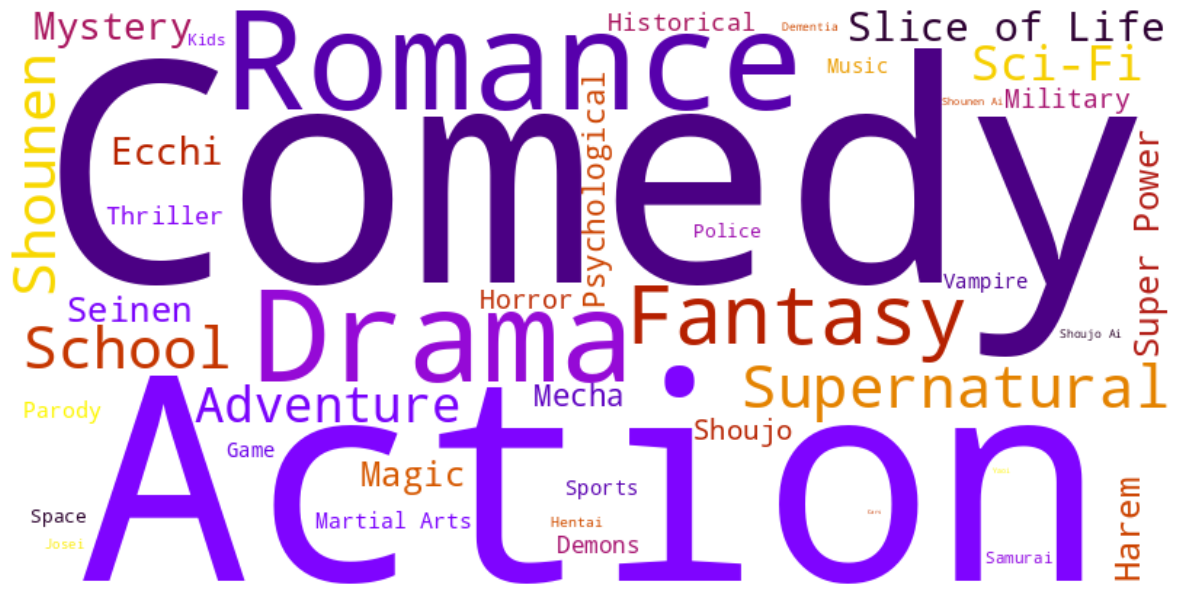

In [ ]:
#vẽ biểu bảng word cloud lên để xem thể loại nào xuất hiện nhiều nhất. Xuất hiện càng nhiều chữ càng to
plt.figure(figsize=(15,10))
# generate_from_frequencies : khởi tạo chữ theo sự thường xuyên
genres_cloud = WordCloud(width=800, height=400, background_color='white', colormap='gnuplot').generate_from_frequencies(all_genres)
plt.imshow(genres_cloud, interpolation='bilinear')
plt.axis('off')

In [ ]:
#10 anime hàng đầu dựa trên số lượng xếp hạng
anime_rating_count = anime_rating.groupby(by = ['name'])['user_rating'].count().reset_index()[['name', 'user_rating']]
anime_rating_count.rename(columns = {'user_rating': 'totalRatingCount'},inplace=True)
anime_rating_count.head()

,name,totalRatingCount
0,0,17
1,0008,34
2,001,10
3,009 ReCyborg,238
4,0091,244


In [ ]:
#10 anime hàng đầu dựa trên số lượng xếp hạng
anime_rating_count = anime_rating.groupby(by = ['name'])['user_rating'].count().reset_index()[['name', 'user_rating']]
anime_rating_count.rename(columns = {'user_rating': 'totalRatingCount'},inplace=True)
anime_rating_count.head()

,name,totalRatingCount
0,0,17
1,0008,34
2,001,10
3,009 ReCyborg,238
4,0091,244


Text(0, 0.5, 'User Rating count')

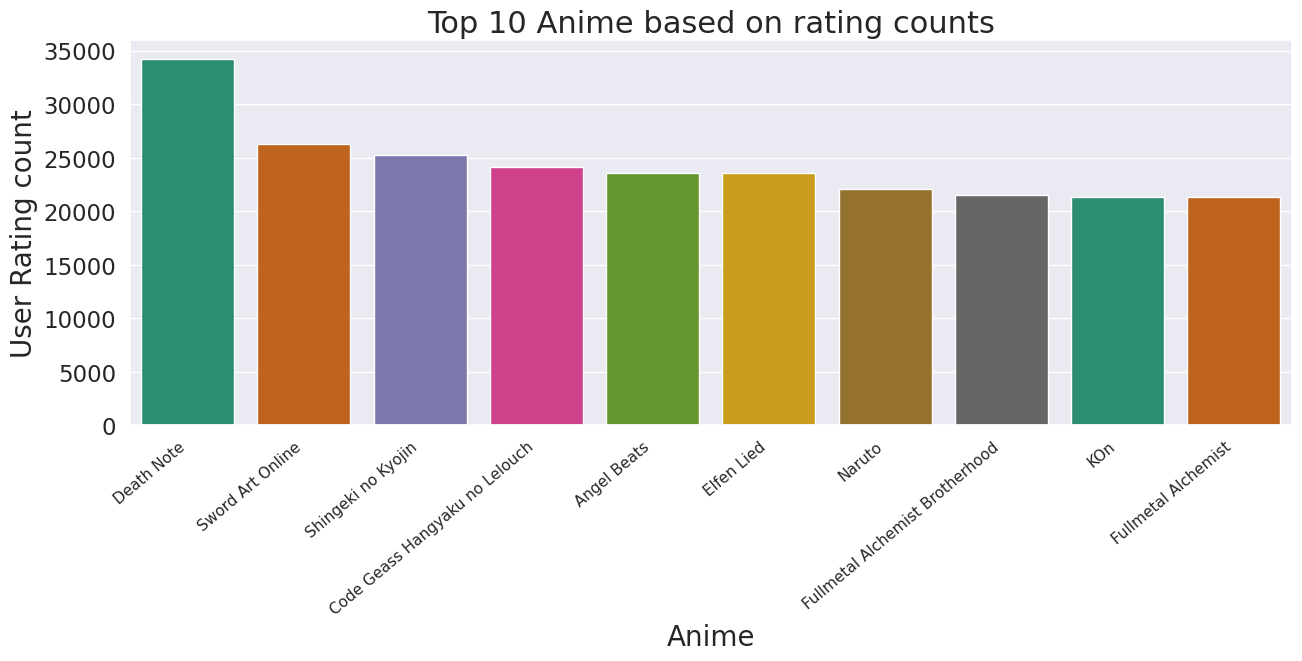

In [ ]:
#top 10 anime
#Thực hiện sort ngược và plot lên biểu đồ
top10_animerating = anime_rating_count[['name', 'totalRatingCount']].sort_values(by = 'totalRatingCount',ascending = False).head(10)
plt.figure(figsize=(15,5))
ax=sns.barplot(x="name", y="totalRatingCount", data=top10_animerating, palette="Dark2")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=40, ha="right")
ax.set_title('Top 10 Anime based on rating counts',fontsize = 22)
ax.set_xlabel('Anime',fontsize = 20)
ax.set_ylabel('User Rating count', fontsize = 20)

### Top 10 animes dựa trên quy mô cộng đồng

In [ ]:
# nối dữ liệu vào làm 1 thành dữ liệu anime rating
# Thực hiện phép left join
anime_rating_data = anime_rating.merge(anime_rating_count, left_on='name', right_on='name', how='left').drop(columns=["Unnamed: 0"])
anime_rating_data.head()

,anime_id,name,genre,type,episodes,avg_rating,members,user_id,user_rating,totalRatingCount
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,99,5.000000,1961
1,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,152,10.000000,1961
2,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,244,10.000000,1961
3,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,271,10.000000,1961
4,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,322,10.000000,1961


In [ ]:
#loại bỏ dữ liệu duplicated
anime_rating_data.duplicated(subset=['name']).sum()

6327268

In [ ]:
anime1 = anime_rating_data.drop_duplicates(subset=['name'])
anime1.head()

,anime_id,name,genre,type,episodes,avg_rating,members,user_id,user_rating,totalRatingCount
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630,99,5.000000,1961
1961,5114,Fullmetal Alchemist Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.260000,793665,3,10.000000,21494
23455,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.250000,114262,43,10.000000,1188
24643,9253,SteinsGate,"Sci-Fi, Thriller",TV,24,9.170000,673572,5,9.000000,17151
41794,9969,Gintama039,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.160000,151266,5,9.000000,3115


Text(0, 0.5, 'Community Size')

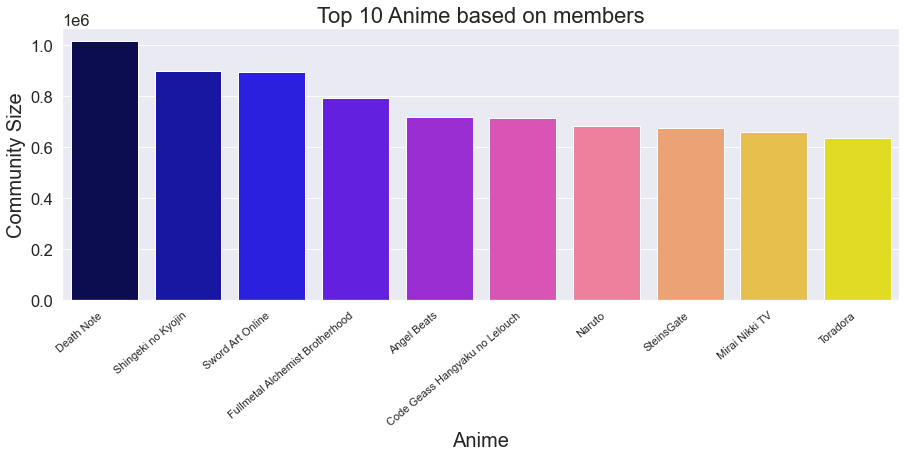

In [ ]:
#top 10 anime
#Thực hiện sort ngược và plot lên biểu đồ
# vẽ biểu đồ barplot để xem top 10 anime
top10_animemembers = anime1[['name', 'members']].sort_values(by = 'members',ascending = False).head(10)
plt.figure(figsize=(15,5))
ax = sns.barplot(x="name", y="members", data=top10_animemembers, palette="gnuplot2")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=40, ha="right")
ax.set_title('Top 10 Anime based on members',fontsize = 22)
ax.set_xlabel('Anime',fontsize = 20)
ax.set_ylabel('Community Size', fontsize = 20)

Text(0.5, 1.0, 'Rating of users')

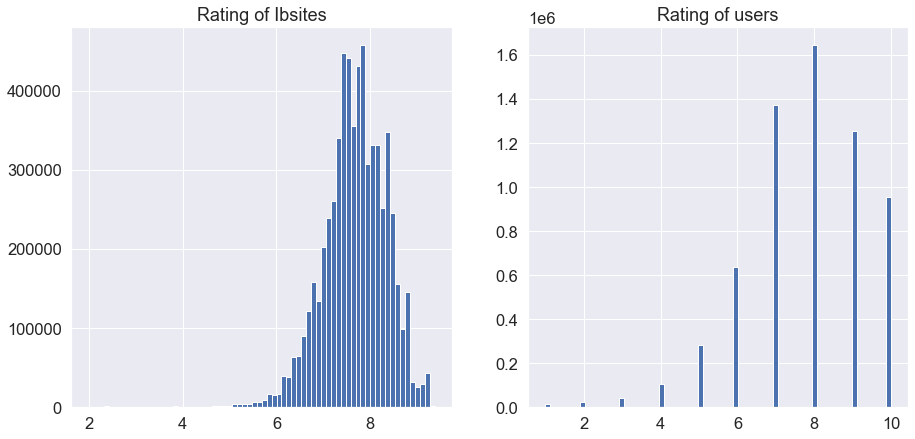

In [ ]:
# Bảng phân phối tần xuất xếp hạng
# Vẽ biểu đồ histogram để xem tần suất phân bổ dữ liệu
plt.figure(figsize = (15, 7))
plt.subplot(1,2,1)
anime_rating['avg_rating'].hist(bins=70)
plt.title("Rating of Ibsites")
plt.subplot(1,2,2)
anime_rating['user_rating'].hist(bins=70)
plt.title("Rating of users")

- Hầu hết các xếp hạng đều chênh lệch nhau từ 6-10.

- Chế độ phân phối là khoảng 7,5-8,0.

- Cả hai phân phối đều là lệch phải.

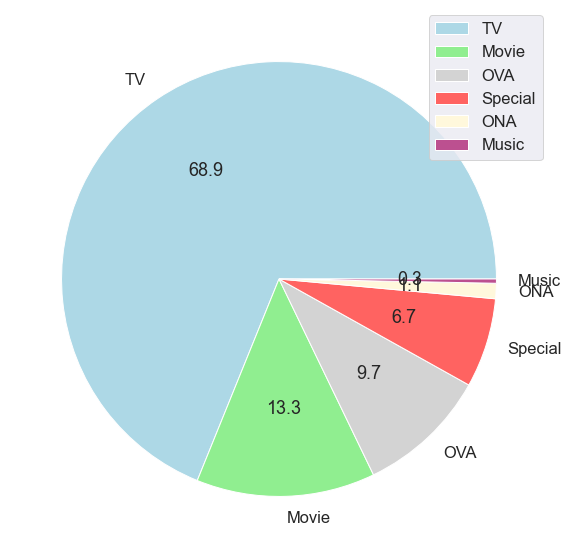

In [ ]:
#Tỉ lệ người xem mỗi loại anime
labels = anime_rating['type'].value_counts().index
values = anime_rating['type'].value_counts().values
plt.figure(figsize=(15,10))
plt.pie(x=values,labels=labels,autopct='%.1f',colors=['lightblue','lightgreen','lightgrey','#FF6361','Cornsilk','#BC5090'])
plt.legend()
plt.show()

In [ ]:
# số lượng các thể loại
d1 = pd.DataFrame(list(dict(all_genres).keys()),columns=['Genre'])

In [ ]:
d2 = pd.DataFrame(list(dict(all_genres).values()),columns=['count'])

In [ ]:
# thống kê số lượng các thể loại
all_genres1 = pd.concat(objs=(d1,d2),axis=1)
all_genres1.head()

,Genre,count
0,Drama,1727681
1,Romance,2031672
2,School,1540797
3,Supernatural,1612455
4,Action,2663837


In [ ]:
all_genres1

,Genre,count
0,Drama,1727681
1,Romance,2031672
2,School,1540797
3,Supernatural,1612455
4,Action,2663837
5,Adventure,1365196
6,Fantasy,1629072
7,Magic,620771
8,Military,364851
9,Shounen,1514010


<AxesSubplot:xlabel='count', ylabel='Genre'>

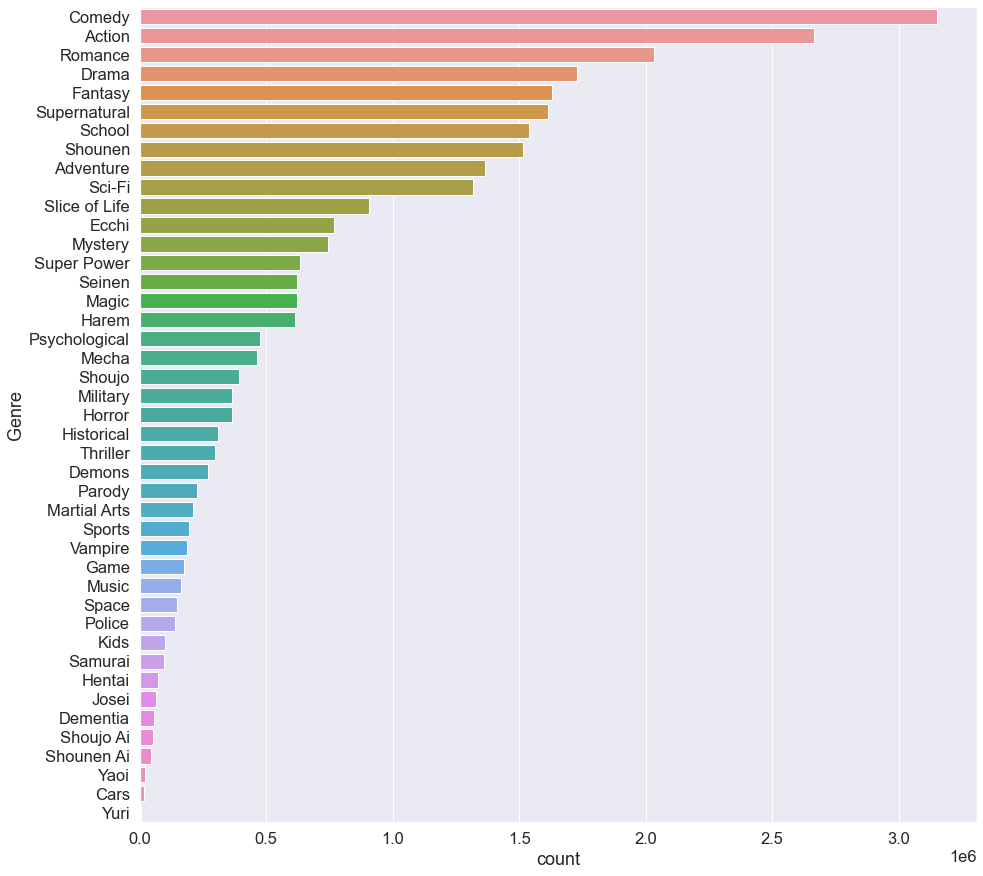

In [ ]:
all_genres1=all_genres1.sort_values(by='count',ascending=False)
plt.figure(figsize=(15,15))
sns.barplot(all_genres1['count'],all_genres1['Genre'])

In [ ]:
## anime = pd.read_csv("anime.csv")

# Luật kết hợp


#### 5.1 Association analysis

In [ ]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630
1,5114,Fullmetal Alchemist Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.260000,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.250000,114262
3,9253,SteinsGate,"Sci-Fi, Thriller",TV,24,9.170000,673572
4,9969,Gintama039,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.160000,151266


In [ ]:
rating = pd.read_csv("/content/drive/My Drive/BTLdataMining/rating.csv",sep=",")
rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


### 5.1.1 By Type

In [ ]:
def get_ar_type(type):
    type_ul=[]
    grouped = rating.groupby("user_id")
    set_type = set(anime[anime["type"] == type]["anime_id"].values)
    print(type+' :',len(set_type))

    for i in rating['user_id'].unique():
        g = grouped.get_group(i)
        r = g[g['rating']>=6]
        set_trans = set(r['anime_id'].values)
        anime_type = list(set_type.intersection(set_trans))
        if len(anime_type)>1:
            type_ul.append(anime_type)

    association_rules = apriori(type_ul, min_support=0.15, min_confidence=0.4, min_lift=1)
    association_results = list(association_rules)

    Result=pd.DataFrame(columns=['Antecedents','Consequents','Support','Confidence','Lift'])
    for item in association_results:
        pair = item[2]
        for i in pair:
            items = str([x for x in i[0]])
            if i[3]!=1:
                Result = Result.append({'Antecedents':str([anime[anime['anime_id']==x].reset_index().loc[0,'name'] for x in i[0]]),'Consequents':str([anime[anime['anime_id']==x].reset_index().loc[0,'name'] for x in i[1]]),'Support':item[1],'Confidence':i[2],'Lift':i[3]},ignore_index=True)
    Result_ar=Result.sort_values(by='Lift',ascending=False)
    Result_ar=Result_ar.reset_index(drop=True)
    return Result_ar

In [ ]:
get_ar_type('Movie').head(10)

Movie : 2258


,Antecedents,Consequents,Support,Confidence,Lift
0,"['Howl no Ugoku Shiro', 'Sen to Chihiro no Kam...",['Tonari no Totoro'],0.151453,0.571773,2.452086
1,['Tonari no Totoro'],"['Sen to Chihiro no Kamikakushi', 'Howl no Ugo...",0.151453,0.649516,2.452086
2,"['Tonari no Totoro', 'Sen to Chihiro no Kamika...",['Howl no Ugoku Shiro'],0.151453,0.779800,2.413385
3,['Howl no Ugoku Shiro'],"['Tonari no Totoro', 'Sen to Chihiro no Kamika...",0.151453,0.468728,2.413385
4,['Howl no Ugoku Shiro'],"['Mononoke Hime', 'Sen to Chihiro no Kamikakus...",0.179896,0.556756,2.323366
5,"['Mononoke Hime', 'Sen to Chihiro no Kamikakus...",['Howl no Ugoku Shiro'],0.179896,0.750714,2.323366
6,"['Howl no Ugoku Shiro', 'Sen to Chihiro no Kam...",['Mononoke Hime'],0.179896,0.679153,2.233547
7,['Mononoke Hime'],"['Sen to Chihiro no Kamikakushi', 'Howl no Ugo...",0.179896,0.591629,2.233547
8,['Tonari no Totoro'],['Howl no Ugoku Shiro'],0.166507,0.714076,2.209976
9,['Howl no Ugoku Shiro'],['Tonari no Totoro'],0.166507,0.515318,2.209976


In [ ]:
get_ar_type('TV').head(10)

TV : 3568


,Antecedents,Consequents,Support,Confidence,Lift
0,['FateZero 2nd Season'],['FateZero'],0.153101,0.973289,5.271606
1,['FateZero'],['FateZero 2nd Season'],0.153101,0.829236,5.271606
2,['Clannad After Story'],"['Angel Beats', 'Clannad']",0.154435,0.661434,3.666252
3,"['Angel Beats', 'Clannad']",['Clannad After Story'],0.154435,0.856014,3.666252
4,['Clannad'],"['Angel Beats', 'Clannad After Story']",0.154435,0.558136,3.475995
5,"['Angel Beats', 'Clannad After Story']",['Clannad'],0.154435,0.961799,3.475995
6,['Clannad'],['Clannad After Story'],0.220128,0.795555,3.407313
7,['Clannad After Story'],['Clannad'],0.220128,0.942795,3.407313
8,"['SteinsGate', 'Code Geass Hangyaku no Lelouch']",['Code Geass Hangyaku no Lelouch R2'],0.152227,0.917383,2.877417
9,['Code Geass Hangyaku no Lelouch R2'],"['SteinsGate', 'Code Geass Hangyaku no Lelouch']",0.152227,0.477466,2.877417


In [ ]:
Result_tv=get_ar_type('TV')

TV : 3568


In [ ]:
Result_movie = get_ar_type('Movie')

Movie : 2258


In [ ]:
def find_anime_ar(name,result):
    temp = result.copy()
    temp['Antecedents'] = temp['Antecedents'].apply(lambda x:x if name in x else 'different')
    temp=temp[temp['Antecedents']!='different']
    temp=temp.reset_index(drop=True)
    return temp

In [ ]:
find_anime_ar('Death Note',Result_tv).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,"['Code Geass Hangyaku no Lelouch', 'Death Note']",['Code Geass Hangyaku no Lelouch R2'],0.235769,0.877368,2.751909
1,"['Code Geass Hangyaku no Lelouch R2', 'Death N...",['Code Geass Hangyaku no Lelouch'],0.235769,0.983371,2.697496
2,"['Sword Art Online', 'Death Note']",['Shingeki no Kyojin'],0.173710,0.744382,1.964254
3,"['Fullmetal Alchemist Brotherhood', 'Death Note']",['Code Geass Hangyaku no Lelouch'],0.157977,0.674082,1.849083
4,"['Shingeki no Kyojin', 'Death Note']",['Fullmetal Alchemist Brotherhood'],0.154251,0.603854,1.845032
5,"['Shingeki no Kyojin', 'Death Note']",['Sword Art Online'],0.173710,0.680034,1.833782
6,"['Code Geass Hangyaku no Lelouch', 'Death Note']",['Fullmetal Alchemist Brotherhood'],0.157977,0.587879,1.796223
7,"['Fullmetal Alchemist Brotherhood', 'Death Note']",['Shingeki no Kyojin'],0.154251,0.658182,1.736794
8,"['Shingeki no Kyojin', 'Death Note']",['Code Geass Hangyaku no Lelouch'],0.151966,0.594909,1.631903
9,"['Code Geass Hangyaku no Lelouch', 'Death Note']",['Shingeki no Kyojin'],0.151966,0.565510,1.492253


In [ ]:
find_anime_ar('Naruto',Result_tv).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,['Naruto'],['Fullmetal Alchemist'],0.151889,0.480545,1.500183
1,['Naruto'],['Fullmetal Alchemist Brotherhood'],0.151874,0.480497,1.468123
2,['Naruto'],['Code Geass Hangyaku no Lelouch'],0.159541,0.504755,1.384598
3,['Naruto'],['Death Note'],0.220665,0.698137,1.360434
4,['Naruto'],['Sword Art Online'],0.158130,0.500291,1.349087
5,['Naruto'],['Shingeki no Kyojin'],0.159618,0.504997,1.332573


In [ ]:
find_anime_ar('Tonari no Totoro', Result_movie).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,['Tonari no Totoro'],"['Sen to Chihiro no Kamikakushi', 'Howl no Ugo...",0.151453,0.649516,2.452086
1,"['Tonari no Totoro', 'Sen to Chihiro no Kamika...",['Howl no Ugoku Shiro'],0.151453,0.779800,2.413385
2,['Tonari no Totoro'],['Howl no Ugoku Shiro'],0.166507,0.714076,2.209976
3,"['Tonari no Totoro', 'Howl no Ugoku Shiro']",['Sen to Chihiro no Kamikakushi'],0.151453,0.909589,2.119941
4,['Tonari no Totoro'],['Sen to Chihiro no Kamikakushi'],0.194220,0.832926,1.941265


## 5.1.2 By Genre

In [ ]:
anime.reset_index(drop=True,inplace=True)

In [ ]:
def get_ar_genre(genre):
    genre_ul=[]
    set_genre=set()
    for i in range(len(anime)):
        str_genre = anime.loc[i, 'genre']
        if pd.isnull(str_genre):
            continue
        A = str_genre.strip().split(", ")
        for j in A:
            if j==genre:
                set_genre.add(anime.loc[i,"anime_id"])

    grouped = rating.groupby("user_id")
    print(genre+' :',len(set_genre))

    for i in rating['user_id'].unique():
        g = grouped.get_group(i)
        r = g[g['rating']>=6]
        set_trans = set(r['anime_id'].values)
        anime_genre = list(set_genre.intersection(set_trans))
        if len(anime_genre)>1:
            genre_ul.append(anime_genre)

    association_rules = apriori(genre_ul, min_support=0.15, min_confidence=0.5,min_lift=1)
    association_results = list(association_rules)

    Result=pd.DataFrame(columns=['Antecedents','Consequents','Support','Confidence','Lift'])
    for item in association_results:
        pair = item[2]
        for i in pair:
            items = str([x for x in i[0]])
            if i[3]!=1:
                Result=Result.append({'Antecedents':str([anime[anime['anime_id']==x].reset_index().loc[0,'name'] for x in i[0]]),'Consequents':str([anime[anime['anime_id']==x].reset_index().loc[0,'name'] for x in i[1]]),'Support':item[1],'Confidence':i[2],'Lift':i[3]},ignore_index=True)
    Result_ar=Result.sort_values(by='Lift',ascending=False)
    Result_ar=Result_ar.reset_index(drop=True)
    return Result_ar

In [ ]:
anime.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa,"Drama, Romance, School, Supernatural",Movie,1,9.370000,200630
1,5114,Fullmetal Alchemist Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.260000,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.250000,114262
3,9253,SteinsGate,"Sci-Fi, Thriller",TV,24,9.170000,673572
4,9969,Gintama039,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.160000,151266


In [ ]:
get_ar_genre('Comedy').head(10)

Comedy : 4483


,Antecedents,Consequents,Support,Confidence,Lift
0,['Clannad'],['Toradora'],0.177051,0.608959,1.847174
1,['Toradora'],['Clannad'],0.177051,0.537055,1.847174
2,['No Game No Life'],['Angel Beats'],0.160876,0.655863,1.783101
3,['Angel Beats'],['Clannad'],0.190108,0.516848,1.777671
4,['Clannad'],['Angel Beats'],0.190108,0.653865,1.777671
5,['Toradora'],['Angel Beats'],0.201144,0.610136,1.658784
6,['Angel Beats'],['Toradora'],0.201144,0.546852,1.658784


In [ ]:
result_drama = get_ar_genre("Drama")

Drama : 1972


In [ ]:
result_action = get_ar_genre('Action')

Action : 2748


In [ ]:
result_action.head()

,Antecedents,Consequents,Support,Confidence,Lift
0,['FateZero'],['FateZero 2nd Season'],0.162466,0.829580,4.969800
1,['FateZero 2nd Season'],['FateZero'],0.162466,0.973289,4.969800
2,['Code Geass Hangyaku no Lelouch R2'],"['Fullmetal Alchemist Brotherhood', 'Code Geas...",0.185784,0.549370,2.686648
3,"['Fullmetal Alchemist Brotherhood', 'Code Geas...",['Code Geass Hangyaku no Lelouch R2'],0.185784,0.908563,2.686648
4,"['Angel Beats', 'Code Geass Hangyaku no Lelouch']",['Code Geass Hangyaku no Lelouch R2'],0.178999,0.905424,2.677367


In [ ]:
result_psychological = get_ar_genre("Psychological")

Psychological : 226


In [ ]:
result_psychological.head()

,Antecedents,Consequents,Support,Confidence,Lift
0,['Higurashi no Naku Koro ni'],['Higurashi no Naku Koro ni Kai'],0.158092,0.685647,4.174874
1,['Higurashi no Naku Koro ni Kai'],['Higurashi no Naku Koro ni'],0.158092,0.962614,4.174874
2,['Tokyo Ghoul √A'],['Tokyo Ghoul'],0.178732,0.970905,3.163724
3,['Tokyo Ghoul'],['Tokyo Ghoul √A'],0.178732,0.582405,3.163724
4,['Neon Genesis Evangelion'],['Neon Genesis Evangelion The End of Evangelion'],0.169327,0.552579,3.157036


In [ ]:
result_comedy = get_ar_genre("Comedy")
result_comedy.head()

Comedy : 4483


,Antecedents,Consequents,Support,Confidence,Lift
0,['Clannad'],['Toradora'],0.177051,0.608959,1.847174
1,['Toradora'],['Clannad'],0.177051,0.537055,1.847174
2,['No Game No Life'],['Angel Beats'],0.160876,0.655863,1.783101
3,['Angel Beats'],['Clannad'],0.190108,0.516848,1.777671
4,['Clannad'],['Angel Beats'],0.190108,0.653865,1.777671


In [ ]:
result_drama.head()

,Antecedents,Consequents,Support,Confidence,Lift
0,"['Angel Beats', 'Clannad']",['Clannad After Story'],0.170107,0.856014,3.332419
1,['Clannad After Story'],"['Angel Beats', 'Clannad']",0.170107,0.662217,3.332419
2,"['Angel Beats', 'Clannad After Story']",['Clannad'],0.170107,0.961799,3.162586
3,['Clannad'],"['Angel Beats', 'Clannad After Story']",0.170107,0.559345,3.162586
4,['Clannad'],['Clannad After Story'],0.242467,0.797279,3.103766


In [ ]:
find_anime_ar('Fullmetal Alchemist',result_action).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,"['Fullmetal Alchemist Brotherhood', 'Code Geas...",['Code Geass Hangyaku no Lelouch R2'],0.185784,0.908563,2.686648
1,"['Fullmetal Alchemist', 'Code Geass Hangyaku n...",['Code Geass Hangyaku no Lelouch R2'],0.169121,0.875864,2.589956
2,"['Code Geass Hangyaku no Lelouch R2', 'Fullmet...",['Code Geass Hangyaku no Lelouch'],0.169121,0.985492,2.552212
3,"['Code Geass Hangyaku no Lelouch R2', 'Fullmet...",['Code Geass Hangyaku no Lelouch'],0.185784,0.981348,2.541479
4,['Fullmetal Alchemist'],['Fullmetal Alchemist Brotherhood'],0.201178,0.593291,1.712599
5,['Fullmetal Alchemist Brotherhood'],['Fullmetal Alchemist'],0.201178,0.580722,1.712599
6,['Fullmetal Alchemist Brotherhood'],"['Code Geass Hangyaku no Lelouch R2', 'Code Ge...",0.185784,0.536286,1.625069
7,['Fullmetal Alchemist Brotherhood'],['Code Geass Hangyaku no Lelouch R2'],0.189315,0.546479,1.615956
8,['Fullmetal Alchemist Brotherhood'],['Code Geass Hangyaku no Lelouch'],0.204481,0.590258,1.528641
9,['Fullmetal Alchemist Brotherhood'],['Shingeki no Kyojin'],0.209607,0.605054,1.512033


In [ ]:
find_anime_ar('Naruto',result_action).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,['Naruto'],['Code Geass Hangyaku no Lelouch'],0.169300,0.507067,1.313194
1,['Naruto'],['Sword Art Online'],0.167803,0.502583,1.282716
2,['Naruto'],['Shingeki no Kyojin'],0.169381,0.507311,1.267771


In [ ]:
find_anime_ar('Gintama°',result_comedy).head(10)

,Antecedents,Consequents,Support,Confidence,Lift


In [ ]:
result_police = get_ar_genre("Police")
result_police.head()

Police : 194


,Antecedents,Consequents,Support,Confidence,Lift
0,['PsychoPass 2'],['PsychoPass'],0.217367,0.982937,2.099345
1,"['PsychoPass 2', 'Death Note']",['PsychoPass'],0.167829,0.982785,2.099021
2,['PsychoPass 2'],"['PsychoPass', 'Death Note']",0.167829,0.758929,1.973162
3,['PsychoPass'],['Death Note'],0.384626,0.821479,1.039782


In [ ]:
find_anime_ar('Death Note',result_police).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,"['PsychoPass 2', 'Death Note']",['PsychoPass'],0.167829,0.982785,2.099021


In [ ]:
find_anime_ar('Death Note',result_psychological).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,"['Mirai Nikki TV', 'Death Note']",['Elfen Lied'],0.163404,0.596108,1.300525
1,['Death Note'],['Elfen Lied'],0.339611,0.519500,1.133390


In [ ]:
result_romance = get_ar_genre("Romance")
result_romance.head()

Romance : 1436


,Antecedents,Consequents,Support,Confidence,Lift
0,['Zero no Tsukaima Futatsuki no Kishi'],['Zero no Tsukaima'],0.157639,0.980181,4.757665
1,['Zero no Tsukaima'],['Zero no Tsukaima Futatsuki no Kishi'],0.157639,0.765156,4.757665
2,['Clannad After Story'],"['Toradora', 'Clannad']",0.160999,0.611930,3.223958
3,"['Toradora', 'Clannad']",['Clannad After Story'],0.160999,0.848225,3.223958
4,['Clannad'],"['Toradora', 'Clannad After Story']",0.160999,0.516219,3.075310


In [ ]:
find_anime_ar('Clannad',result_comedy).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,['Clannad'],['Toradora'],0.177051,0.608959,1.847174
1,['Clannad'],['Angel Beats'],0.190108,0.653865,1.777671


In [ ]:
find_anime_ar('Zero no Tsukaima Futatsuki no Kishi',result_romance).head(10)

,Antecedents,Consequents,Support,Confidence,Lift
0,['Zero no Tsukaima Futatsuki no Kishi'],['Zero no Tsukaima'],0.157639,0.980181,4.757665
